2. Transformer-Based Text Generation Pipeline  

In [ ]:
from datasets import DatasetDict, load_dataset

raw = load_dataset("wikimedia/wikipedia", "20231101.simple", split="train")
raw = raw.shuffle(seed=42).select(range(120000))
split = raw.train_test_split(test_size=0.1, seed=42)
held = split["test"].train_test_split(test_size=0.5, seed=42)
ds = DatasetDict({"train": split["train"], "validation": held["train"], "test": held["test"]})
ds = ds.remove_columns(["id", "url", "title"])

2.1 Data Gathering & Preprocessing

In [ ]:
ds.column_names

{'train': ['text'], 'validation': ['text'], 'test': ['text']}

In [ ]:
import re
_tail = re.compile(r"\n(?:References|Other websites|Related pages|Sources|Further reading|External links)[ \t]*(?:\n|$)")

def clean(x):
  t = _tail.split(x["text"], maxsplit=1)[0][:20000]
  return {"text": " ".join(t.split())}

ds_clean = ds.map(clean, num_proc=4)

Map (num_proc=4):   0%|          | 0/108000 [00:00<?, ? examples/s]

Map (num_proc=4):   0%|          | 0/6000 [00:00<?, ? examples/s]

Map (num_proc=4):   0%|          | 0/6000 [00:00<?, ? examples/s]

In [ ]:
def is_valid(x):# strps unwanted char and checks if empty and if the dataset form of headings using "=" is in the text
  s=x["text"].strip()
  if not s:
    return False
  if len(s) < 300:
    return False
  return True
ds_clean=ds_clean.filter(is_valid,num_proc=4)

Filter (num_proc=4):   0%|          | 0/108000 [00:00<?, ? examples/s]

Filter (num_proc=4):   0%|          | 0/6000 [00:00<?, ? examples/s]

Filter (num_proc=4):   0%|          | 0/6000 [00:00<?, ? examples/s]

In [ ]:
from transformers import AutoTokenizer
tokenizer=AutoTokenizer.from_pretrained("gpt2")
tokenizer.pad_token=tokenizer.eos_token

In [ ]:
#tokenize all splits using a pretrained Byte-Pair Encoding tokenizer
def tokenize_function(x):
    encoded = tokenizer(x["text"])

    encoded["input_ids"] = [
        ids + [tokenizer.eos_token_id]
        for ids in encoded["input_ids"]]
    encoded["attention_mask"] = [
        mask + [1]
        for mask in encoded["attention_mask"]]

    return encoded
tokenized_ds = ds_clean.map(tokenize_function,batched=True,num_proc=4, remove_columns=["text"])

Map (num_proc=4):   0%|          | 0/67117 [00:00<?, ? examples/s]

Token indices sequence length is longer than the specified maximum sequence length for this model (1234 > 1024). Running this sequence through the model will result in indexing errors
Token indices sequence length is longer than the specified maximum sequence length for this model (1786 > 1024). Running this sequence through the model will result in indexing errors
Token indices sequence length is longer than the specified maximum sequence length for this model (2158 > 1024). Running this sequence through the model will result in indexing errors
Token indices sequence length is longer than the specified maximum sequence length for this model (1583 > 1024). Running this sequence through the model will result in indexing errors


Map (num_proc=4):   0%|          | 0/3741 [00:00<?, ? examples/s]

Token indices sequence length is longer than the specified maximum sequence length for this model (2154 > 1024). Running this sequence through the model will result in indexing errors
Token indices sequence length is longer than the specified maximum sequence length for this model (1132 > 1024). Running this sequence through the model will result in indexing errors
Token indices sequence length is longer than the specified maximum sequence length for this model (1663 > 1024). Running this sequence through the model will result in indexing errors
Token indices sequence length is longer than the specified maximum sequence length for this model (1984 > 1024). Running this sequence through the model will result in indexing errors


Map (num_proc=4):   0%|          | 0/3710 [00:00<?, ? examples/s]

Token indices sequence length is longer than the specified maximum sequence length for this model (1097 > 1024). Running this sequence through the model will result in indexing errors
Token indices sequence length is longer than the specified maximum sequence length for this model (4044 > 1024). Running this sequence through the model will result in indexing errors
Token indices sequence length is longer than the specified maximum sequence length for this model (1053 > 1024). Running this sequence through the model will result in indexing errors
Token indices sequence length is longer than the specified maximum sequence length for this model (1821 > 1024). Running this sequence through the model will result in indexing errors


In [ ]:
#group texts into fixed 128 tokens
block_size=128
def group_text(x):
  concatenated_x = {k: sum(x[k], []) for k in x.keys()}
  total_length = len(concatenated_x[list(x.keys())[0]])
  total_length = (total_length//block_size) * block_size
  result = {k: [t[i : i + block_size] for i in range(0, total_length, block_size)]for k, t in concatenated_x.items()}
  result["labels"] = result["input_ids"].copy()
  return result
blocked_ds=tokenized_ds.map(group_text,batched=True,num_proc=4)

Map (num_proc=4):   0%|          | 0/67117 [00:00<?, ? examples/s]

Map (num_proc=4):   0%|          | 0/3741 [00:00<?, ? examples/s]

Map (num_proc=4):   0%|          | 0/3710 [00:00<?, ? examples/s]

In [ ]:
print(blocked_ds)

DatasetDict({
    train: Dataset({
        features: ['input_ids', 'attention_mask', 'labels'],
        num_rows: 166277
    })
    validation: Dataset({
        features: ['input_ids', 'attention_mask', 'labels'],
        num_rows: 9439
    })
    test: Dataset({
        features: ['input_ids', 'attention_mask', 'labels'],
        num_rows: 9219
    })
})


## 2.2 Transformer Model Implementation

In [ ]:
# importing libraries
import copy
import math
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader

block_size = 128
d_model = 384
num_heads = 6
num_layers =8
dropout= 0.1
batch_size=32
num_epochs = 5
learning_rate = 5e-4
vocab_size = len(tokenizer)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [ ]:
class MultiHeadAttention(nn.Module):
  def __init__(self, d_model, num_heads, max_seq_len, dropout=0.1):
      super().__init__()

      if d_model % num_heads != 0:
          raise ValueError("d_model must be divisible by num_heads")

      self.d_model = d_model
      self.num_heads = num_heads
      self.head_dim = d_model // num_heads

      self.query = nn.Linear(d_model, d_model)
      self.key = nn.Linear(d_model, d_model)
      self.value = nn.Linear(d_model, d_model)
      self.output_proj = nn.Linear(d_model, d_model)
      self.attention_dropout = nn.Dropout(dropout)
      self.output_dropout = nn.Dropout(dropout)
      self.attn_dropout_p = dropout
      self.use_sdpa = True # set False for the manual path (needed for the heatmap bonus)

      causal_mask = torch.tril(
          torch.ones(max_seq_len, max_seq_len)).bool()
      self.register_buffer("causal_mask", causal_mask)

  def forward(self, x):
      batch_size, seq_len, _ = x.shape

      q = self.query(x)
      k = self.key(x)
      v = self.value(x)

      q = q.view(batch_size, seq_len, self.num_heads, self.head_dim).transpose(1, 2)
      k = k.view(batch_size, seq_len, self.num_heads, self.head_dim).transpose(1, 2)
      v = v.view(batch_size, seq_len, self.num_heads, self.head_dim).transpose(1, 2)

      if self.use_sdpa:
          attended = F.scaled_dot_product_attention(
              q, k, v,
              dropout_p=self.attn_dropout_p if self.training else 0.0,
              is_causal=True,
          )
      else:
          scores = q @ k.transpose(-2, -1)
          scores = scores / math.sqrt(self.head_dim)

          mask = self.causal_mask[:seq_len, :seq_len]
          scores = scores.masked_fill(~mask, float("-inf"))

          weights = F.softmax(scores, dim=-1)
          weights = self.attention_dropout(weights)

          attended = weights @ v
      attended = attended.transpose(1, 2).contiguous()
      attended = attended.view(batch_size, seq_len, self.d_model)
      return self.output_dropout(self.output_proj(attended))

In [ ]:
class TransformerBlock(nn.Module):
  def __init__(self, d_model, num_heads, max_seq_len, dropout=0.1):
    super().__init__()
    self.layer_norm_1 = nn.LayerNorm(d_model)
    self.attention = MultiHeadAttention(
        d_model= d_model, num_heads=num_heads,
        max_seq_len=max_seq_len, dropout=dropout
    )
    self.layer_norm_2 = nn.LayerNorm(d_model)

    self.feed_forward = nn.Sequential(
        nn.Linear(d_model, 4*d_model),
        nn.GELU(),
        nn.Linear(4*d_model, d_model),
        nn.Dropout(dropout)
    )
  def forward(self, x):
    x = x + self.attention(self.layer_norm_1(x))
    x = x + self.feed_forward(self.layer_norm_2(x))
    return x

In [ ]:
class CausalTransformer(nn.Module):
  def __init__(self, vocab_size, d_model=256, num_heads=4, num_layers=2, max_seq_len=128, dropout=0.1):
    super().__init__()
    self.max_seq_len = max_seq_len

    self.token_embedding = nn.Embedding(vocab_size, d_model)
    self.position_embedding = nn.Embedding(max_seq_len, d_model)
    self.embedding_dropout = nn.Dropout(dropout)

    self.blocks = nn.ModuleList([
        TransformerBlock(d_model=d_model, num_heads=num_heads, max_seq_len=max_seq_len, dropout=dropout)
        for _ in range(num_layers)
    ])

    self.final_layer_norm = nn.LayerNorm(d_model)

    self.output_layer = nn.Linear(d_model, vocab_size, bias=False)
    self.output_layer.weight = self.token_embedding.weight
    self.apply(self._init_weights)

  def _init_weights(self, module):
    if isinstance(module, nn.Linear):
      nn.init.normal_(module.weight, mean=0.0, std=0.02)
      if module.bias is not None:
        nn.init.zeros_(module.bias)
    elif isinstance(module, nn.Embedding):
      nn.init.normal_(module.weight, mean=0.0, std=0.02)

  def forward(self, input_ids):
    batch_size, seq_len = input_ids.shape
    if seq_len > self.max_seq_len:
      raise ValueError(f"input length {seq_len} is over the max sequence length {self.max_seq_len}")
    positions = torch.arange(seq_len, device=input_ids.device)
    token_vectors = self.token_embedding(input_ids)
    position_vectors = self.position_embedding(positions)
    x = self.embedding_dropout(token_vectors + position_vectors)
    for block in self.blocks:
      x = block(x)
    x = self.final_layer_norm(x)
    logits = self.output_layer(x)
    return logits

In [ ]:
model = CausalTransformer(
    vocab_size=vocab_size,
    d_model=d_model,
    num_heads=num_heads,
    num_layers=num_layers,
    max_seq_len=block_size,
    dropout=dropout
).to(device)

In [ ]:
train_dataset = blocked_ds["train"].with_format(
    "torch", columns=["input_ids", "labels"]
)
validation_dataset = blocked_ds["validation"].with_format(
    "torch", columns=["input_ids", "labels"]
)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
validation_dataloader = DataLoader(validation_dataset, batch_size=batch_size, shuffle=False)

In [ ]:
optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate, betas=(0.9, 0.95), weight_decay=0.1)
loss_fn = nn.CrossEntropyLoss()
scaler = torch.amp.GradScaler("cuda", enabled=(device.type == "cuda"))

In [ ]:
def calc_loss_for_loader(model, loader, training):
    if training:
        model.train()
    else:
        model.eval()

    total_loss = 0.0
    total_tokens = 0
    context = torch.enable_grad() if training else torch.no_grad()

    with context:
        for batch in loader:
            input_ids = batch["input_ids"].to(device)
            labels = batch["labels"].to(device)

            if training:
                optimizer.zero_grad(set_to_none=True)

            with torch.autocast(device_type="cuda", dtype=torch.float16, enabled=(device.type == "cuda")):
                logits = model(input_ids)

                predictions = logits[:, :-1, :].contiguous()
                targets = labels[:, 1:].contiguous()

                loss = loss_fn(
                    predictions.view(-1, vocab_size),
                    targets.view(-1),
                )

            if training:
                scaler.scale(loss).backward()
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                scaler.step(optimizer)
                scaler.update()

            num_targets = targets.numel()
            total_loss += loss.item() * num_targets
            total_tokens += num_targets

    avg_loss = total_loss / total_tokens
    perplexity = math.exp(min(avg_loss, 80))
    return avg_loss, perplexity

In [ ]:
from pathlib import Path
import copy

best_val_loss = float("inf")
best_model_state = None
best_epoch = 0
patience = 3
epochs_without_improvement = 0

save_dir = Path("saved_model")
save_dir.mkdir(parents=True, exist_ok=True)
model_path = save_dir / "causal_transformer_best.pt"

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs, eta_min=1e-5)
history = {"train_loss": [], "val_loss": [], "train_ppl": [], "val_ppl": []}

for epoch in range(1, num_epochs + 1):
    train_loss, train_perplexity = calc_loss_for_loader(
        model, train_loader, training=True
    )
    val_loss, val_perplexity = calc_loss_for_loader(
        model, validation_dataloader, training=False
    )
    scheduler.step()

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_ppl"].append(train_perplexity)
    history["val_ppl"].append(val_perplexity)

    print(
        f"Epoch {epoch}/{num_epochs} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Perplexity: {val_perplexity:.2f}"
    )

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_epoch = epoch
        best_model_state = copy.deepcopy(model.state_dict())
        epochs_without_improvement = 0

        torch.save(
            {
                "model_state_dict": best_model_state,
                "model_config": {
                    "vocab_size": vocab_size,
                    "d_model": d_model,
                    "num_heads": num_heads,
                    "num_layers": num_layers,
                    "max_seq_len": block_size,
                    "dropout": dropout,
                },
                "best_epoch": best_epoch,
                "best_val_loss": best_val_loss,
            },
            model_path,
        )
        print(f" Saved best model to {model_path}")
    else:
        epochs_without_improvement += 1

    if epochs_without_improvement >= patience:
        print("Stopping: validation loss did not improve.")
        break

if best_model_state is not None:
    model.load_state_dict(best_model_state)

print(f"Best epoch: {best_epoch}")
print(f"Best validation loss: {best_val_loss:.4f}")
print(f"Best validation perplexity: {math.exp(min(best_val_loss, 80)):.2f}")

Epoch 1/5 | Train Loss: 5.4276 | Val Loss: 4.7798 | Val Perplexity: 119.08
 Saved best model to saved_model/causal_transformer_best.pt
Epoch 2/5 | Train Loss: 4.6207 | Val Loss: 4.4360 | Val Perplexity: 84.44
 Saved best model to saved_model/causal_transformer_best.pt
Epoch 3/5 | Train Loss: 4.3672 | Val Loss: 4.2818 | Val Perplexity: 72.37
 Saved best model to saved_model/causal_transformer_best.pt
Epoch 4/5 | Train Loss: 4.2075 | Val Loss: 4.1726 | Val Perplexity: 64.88
 Saved best model to saved_model/causal_transformer_best.pt
Epoch 5/5 | Train Loss: 4.0908 | Val Loss: 4.1013 | Val Perplexity: 60.42
 Saved best model to saved_model/causal_transformer_best.pt
Best epoch: 5
Best validation loss: 4.1013
Best validation perplexity: 60.42


In [ ]:
test_dataset = blocked_ds["test"].with_format("torch", columns=["input_ids", "labels"])
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
test_loss, test_ppl = calc_loss_for_loader(model, test_loader, training=False)
print(f"test loss: {test_loss:.4f} | test perp: {test_ppl:.2f}")

test loss: 4.1073 | test perp: 60.78


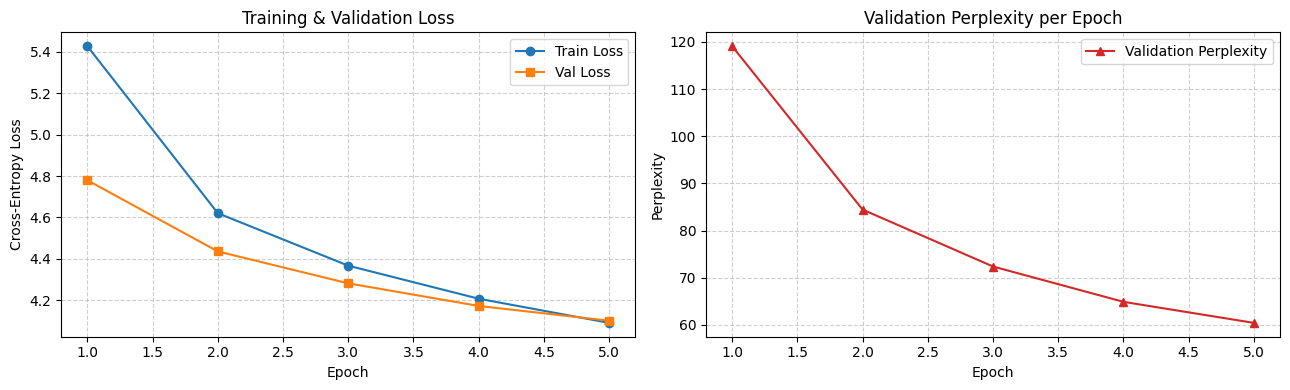

In [ ]:
# Plot training metrics required for Task 2 Report
import matplotlib.pyplot as plt

def plot_training_results(history):
    epochs = range(1, len(history["train_loss"]) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    axes[0].plot(epochs, history["train_loss"], marker="o", label="Train Loss", color="#1f77b4")
    axes[0].plot(epochs, history["val_loss"], marker="s", label="Val Loss", color="#ff7f0e")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Cross-Entropy Loss")
    axes[0].set_title("Training & Validation Loss")
    axes[0].grid(True, linestyle="--", alpha=0.6)
    axes[0].legend()

    axes[1].plot(epochs, history["val_ppl"], marker="^", label="Validation Perplexity", color="#d62728")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Perplexity")
    axes[1].set_title("Validation Perplexity per Epoch")
    axes[1].grid(True, linestyle="--", alpha=0.6)
    axes[1].legend()

    plt.tight_layout()
    plt.savefig("transformer_training_metrics.png", dpi=300)
    plt.show()

plot_training_results(history)

In [ ]:
@torch.no_grad()
def generate_text(prompt, max_new_tokens=30, temperature=0.7, top_k=40, top_p=0.9, repetition_penalty=1.15):
  if temperature <= 0:
      raise ValueError("temperature must be greater than 0")

  model.eval()
  prompt_ids = tokenizer.encode(prompt, add_special_tokens=False)

  if not prompt_ids:
      prompt_ids = [tokenizer.eos_token_id]
  input_ids = torch.tensor(
      [prompt_ids],
      dtype=torch.long,
      device=device
  )

  for _ in range(max_new_tokens):
      context_ids = input_ids[:, -model.max_seq_len:]
      logits = model(context_ids)
      next_token_logits = logits[:, -1, :] / temperature

      if repetition_penalty != 1.0:
          seen = torch.unique(context_ids)
          score = next_token_logits[:, seen]
          next_token_logits[:, seen] = torch.where(score > 0, score / repetition_penalty, score * repetition_penalty)

      if top_k is not None and top_k > 0:
          kth = torch.topk(next_token_logits, min(top_k, next_token_logits.size(-1))).values[:, -1, None]
          next_token_logits = next_token_logits.masked_fill(next_token_logits < kth, float("-inf"))

      if top_p is not None and top_p < 1.0:
          sorted_logits, sorted_idx = torch.sort(next_token_logits, descending=True)
          sorted_probs = F.softmax(sorted_logits, dim=-1)
          cum_probs = torch.cumsum(sorted_probs, dim=-1)
          remove = (cum_probs - sorted_probs) > top_p
          sorted_logits = sorted_logits.masked_fill(remove, float("-inf"))
          next_token_logits = torch.full_like(next_token_logits, float("-inf")).scatter(-1, sorted_idx, sorted_logits)

      probabilities = F.softmax(next_token_logits, dim=-1)
      next_token = torch.multinomial(probabilities, num_samples=1)

      input_ids = torch.cat([input_ids, next_token], dim=1)

  text = tokenizer.decode(input_ids[0].tolist())
  return text.replace(tokenizer.eos_token, "\n")


print(generate_text("The history of science", max_new_tokens=30, temperature=0.8))

The history of science is not a collection of information. It was discovered in 1843 by James R. Johnson. It is now in the National Museum of Science and Sciences


In [ ]:
"""
this is the code to save the model with it's current parameters without having to
train everytime because it will take a lot of time
"""

save_dir = Path("saved_model")
save_dir.mkdir(parents=True, exist_ok=True)

model_path = save_dir / "causal_transformer.pt"
tokenizer_path = save_dir / "tokenizer"

torch.save(
    {
        "model_state_dict": model.state_dict(),
        "model_config": {
            "vocab_size": vocab_size,
            "d_model": d_model,
            "num_heads": num_heads,
            "num_layers": num_layers,
            "max_seq_len": block_size,
            "dropout": dropout,
        },
    },
    model_path,
)

tokenizer.save_pretrained(tokenizer_path)
print(f"Model saved to: {model_path}")

Model saved to: saved_model/causal_transformer.pt


In [ ]:
"""
this is the code to load the model for use again
to run just remove the "#"
"""

# checkpoint = torch.load(model_path, map_location=device)

# model = CausalTransformer(**checkpoint["model_config"]).to(device)
# model.load_state_dict(checkpoint["model_state_dict"])
# model.eval()

# tokenizer = AutoTokenizer.from_pretrained(tokenizer_path)
# tokenizer.pad_token = tokenizer.eos_token

'\nthis is the code to load the model for use again\nto run just remove the "#"\n'

In [ ]:
import matplotlib.pyplot as plt

@torch.no_grad()
def get_attention_weights(token_ids, layer=-1, head=0):
    """Return (T, T) attention weights of one head in one layer for a token sequence."""
    model.eval()
    ids = torch.tensor([token_ids[-model.max_seq_len:]], dtype=torch.long, device=device)

    attn = model.blocks[layer].attention
    captured = {}
    handle = attn.register_forward_hook(lambda m, inp, out: captured.update(x=inp[0]))
    model(ids)
    handle.remove()

    x = captured["x"]
    B, T, _ = x.shape
    H, hd = attn.num_heads, attn.head_dim
    q = attn.query(x).view(B, T, H, hd).transpose(1, 2)
    k = attn.key(x).view(B, T, H, hd).transpose(1, 2)

    scores = (q @ k.transpose(-2, -1)) / math.sqrt(hd)
    scores = scores.masked_fill(~attn.causal_mask[:T, :T], float("-inf"))
    weights = F.softmax(scores, dim=-1)
    return weights[0, head].cpu().numpy(), ids[0].tolist()


def plot_attention_heatmap(prompt, max_new_tokens=15, temperature=0.8,
                           layer=-1, head=0, max_tokens_shown=40):
    text = generate_text(prompt, max_new_tokens=max_new_tokens, temperature=temperature)
    token_ids = tokenizer.encode(text, add_special_tokens=False)

    weights, ids = get_attention_weights(token_ids, layer=layer, head=head)

    weights = weights[-max_tokens_shown:, -max_tokens_shown:]
    labels = [tokenizer.decode([t]).replace("\n", "\\n") for t in ids[-max_tokens_shown:]]

    fig, ax = plt.subplots(figsize=(10, 8))
    im = ax.imshow(weights, cmap="viridis")
    ax.set_xticks(range(len(labels)))
    ax.set_yticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=90)
    ax.set_yticklabels(labels)
    ax.set_xlabel("Attended-to token (key)")
    ax.set_ylabel("Current token (query)")
    ax.set_title(f"Attention heatmap - layer {layer}, head {head}")
    fig.colorbar(im, ax=ax, label="attention weight")
    plt.tight_layout()
    plt.savefig("attention_heatmap.png", dpi=300)
    plt.show()
    return text


plot_attention_heatmap("The history of science", max_new_tokens=15, temperature=0.8, layer=-1, head=0)